In [1]:
import numpy as np

#Define network

이전 주차의 TwoLayerNet에서 레이어 수, 가중치 초기화 및 감소, dropout, batchnorm 기능을 추가하였습니다.

**self.__init_weight()**과 **self.loss()**의 빈칸을 채워주세요!

In [2]:
from collections import OrderedDict

class MultiLayerNet:
    '''
    input_size: 입력 크기 (MNIST의 경우 784)
    hidden_size_list: 은닉층 뉴런 개수의 리스트 (예: [100,100,100])
    output_size: 출력 크기 (MNIST의 경우 10)
    activation: 'relu' 또는 'sigmoid'
    weight_init_std: 가중치의 표준 편차 지정 (예: 0.01)
    'relu' 또는 'he'를 지정하면 He 초기화를 설정
    'sigmoid' 또는 'xavier'를 지정하면 Xavier 초기화를 설정
    weight_decay_lambda: Weight Decay(L2 정규화)의 강도
    use_dropout: Dropout을 사용할지 여부
    dropout_ration: Dropout 비율
    use_batchNorm: Batch Normalization을 사용할지 여부
    '''

    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0,
                 use_dropout = False, dropout_ration = 0.5, use_batchnorm=False):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.use_dropout = use_dropout
        self.weight_decay_lambda = weight_decay_lambda
        self.use_batchnorm = use_batchnorm
        self.params = {}

        self.__init_weight(weight_init_std)

        # 레이어 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            if self.use_batchnorm:
                self.params['gamma' + str(idx)] = np.ones(hidden_size_list[idx-1])
                self.params['beta' + str(idx)] = np.zeros(hidden_size_list[idx-1])
                self.layers['BatchNorm' + str(idx)] = BatchNormalization(self.params['gamma' + str(idx)], self.params['beta' + str(idx)])

            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

            if self.use_dropout:
                self.layers['Dropout' + str(idx)] = Dropout(dropout_ration)

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)], self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()


    def __init_weight(self, weight_init_std):
        """가중치 초기값 설정
        weight_init_std : 가중치의 표준 편차 지정 (예: 0.01)
        'relu' 또는 'he'를 지정하면 "He 초기화"를 설정
        'sigmoid' 또는 'xavier'를 지정하면 "Xavier 초기화"를 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2 / all_size_list[idx-1])  # ReLU
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(2 / (all_size_list[idx-1] + all_size_list[idx]))  # sigmoid
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])


    def predict(self, x, train_flg=False):
        for key, layer in self.layers.items():
            if "Dropout" in key or "BatchNorm" in key:
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)

        return x


    def loss(self, x, t, train_flg=False):
        """손실 함수 정의
        입력 값 x는 입력 데이터, t는 정답 레이블
        """
        y = self.predict(x, train_flg)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)

        return self.last_layer.forward(y, t) + weight_decay


    def accuracy(self, x, t):
        y = self.predict(x, train_flg=False)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy


    def gradient(self, x, t):
        # forward
        self.loss(x, t, train_flg=True)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)


        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.params['W' + str(idx)]
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

            if self.use_batchnorm and idx != self.hidden_layer_num+1:
                grads['gamma' + str(idx)] = self.layers['BatchNorm' + str(idx)].dgamma
                grads['beta' + str(idx)] = self.layers['BatchNorm' + str(idx)].dbeta

        return grads

#Layers

각 레이어에는 init, forward, backward 함수가 정의되어 있습니다.

sigmoid 계층이 추가되었습니다.

In [3]:
class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b

        self.x = None
        self.original_x_shape = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)
        return dx

In [4]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [5]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

In [6]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size:
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx

#Functions

복습차원에서 빈칸을 채워봅시다!

In [7]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

In [8]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

#Optimizers

파라미터와 기울기를 인수로 받아서 파라미터를 갱신합니다.

Adam optimizer가 추가되었습니다.

In [9]:
class SGD:

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [10]:
class Momentum:

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

In [11]:
class AdaGrad:

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

In [12]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1  # momentum
        self.beta2 = beta2  # adagrad
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1
        # 시간에 따른 학습률 변화
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)


        for key in params.keys():
            self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)

            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

# Regularization

**BatchNormalization**

배치 단위로 정규화하고, 감마와 베타의 기울기를 구하는 과정을 살펴보세요.

계산 그래프에서 dx가 전달되는 과정을 알게 쉽게 설명한 글입니다!

https://kratzert.github.io/2016/02/12/understanding-the-gradient-flow-through-the-batch-normalization-layer.html

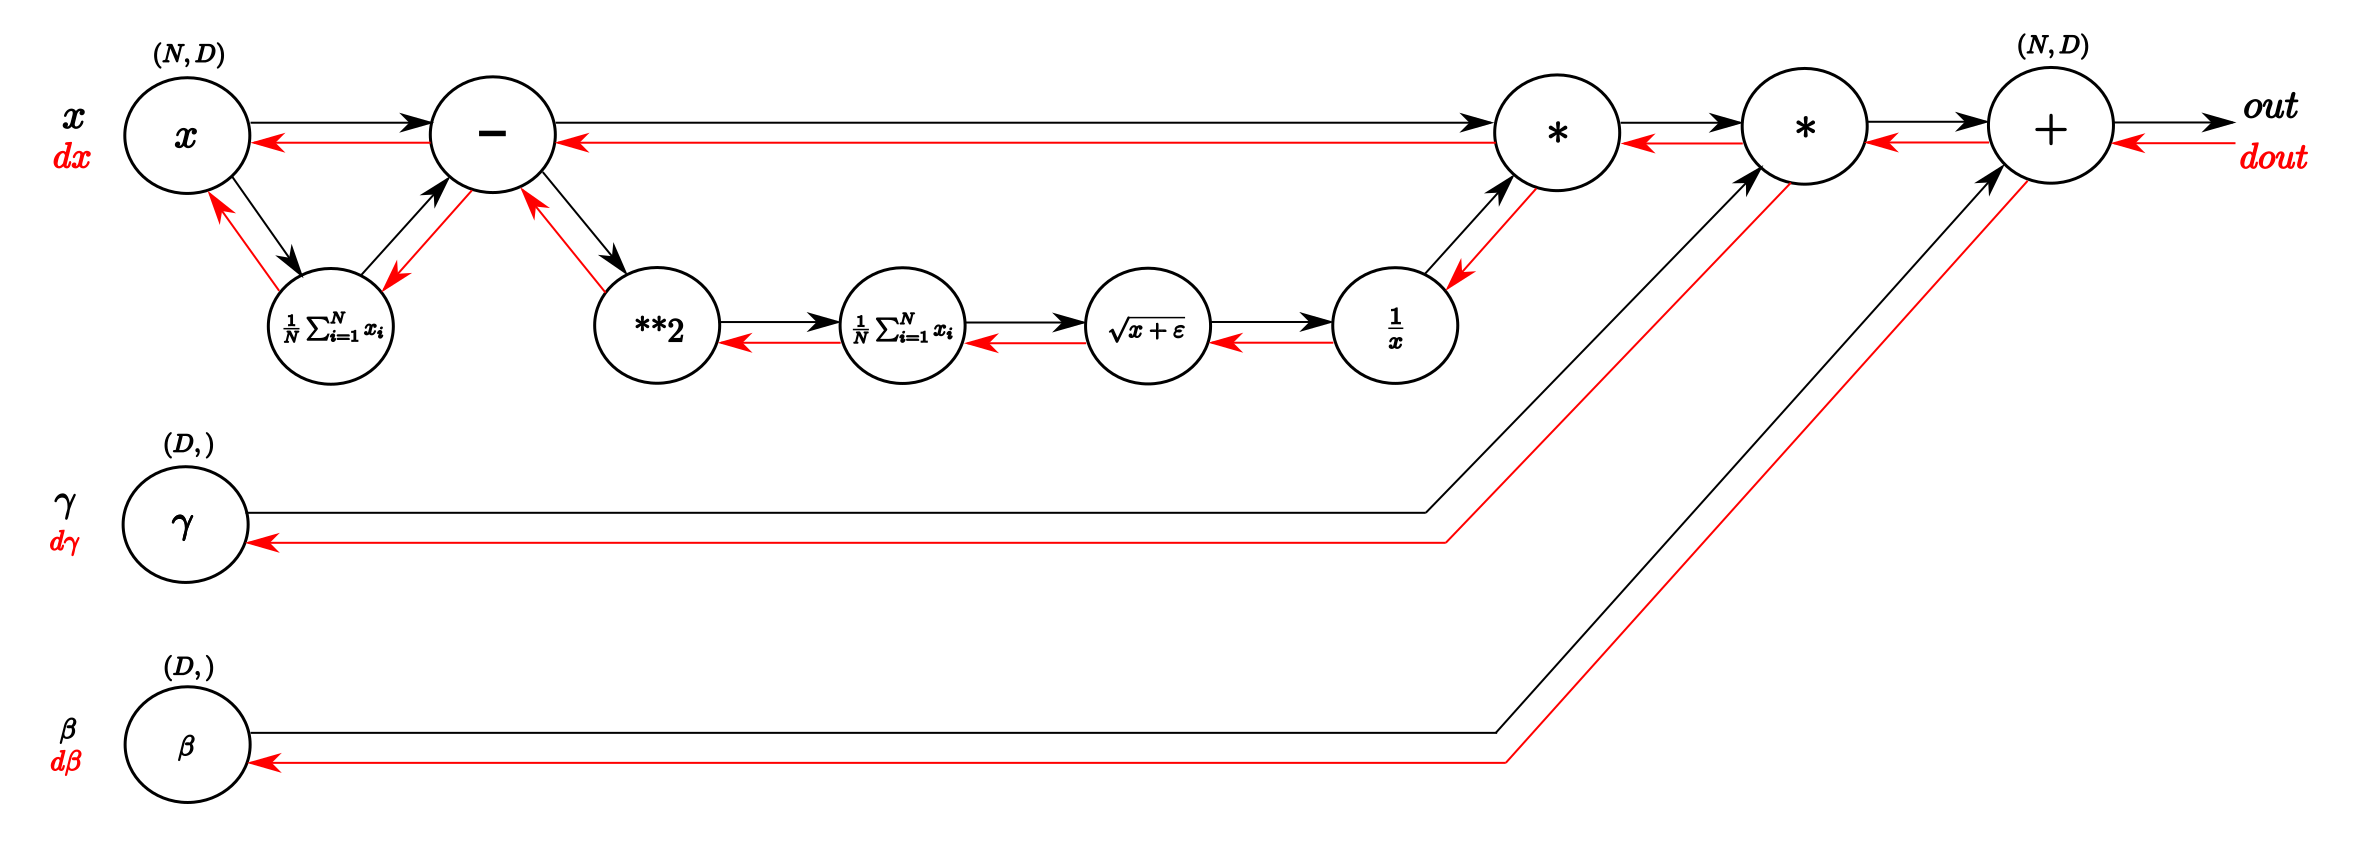

In [13]:
class BatchNormalization:
  """
  http://arxiv.org/abs/1502.03167
  """
  def __init__(self, gamma, beta, momentum=0.9, running_mean=None, running_var=None):
      self.gamma = gamma
      self.beta = beta
      self.momentum = momentum
      self.input_shape = None # Conv 층=4차원, 완전 연결층=2차원

      # 테스트 시 사용하는 평균과 분산(즉, 업데이트 대상)
      self.running_mean = running_mean
      self.running_var = running_var

      # backward 시에 사용하는 중간 데이터
      self.batch_size = None
      self.xc = None
      self.std = None
      self.dgamma = None
      self.dbeta = None

  def forward(self, x, train_flg=True):
      self.input_shape = x.shape
      if x.ndim != 2:
          N, C, H, W = x.shape
          x = x.reshape(N, -1)

      out = self.__forward(x, train_flg)

      return out.reshape(*self.input_shape)


  def __forward(self, x, train_flg):
      if self.running_mean is None:
          N, D = x.shape
          self.running_mean = np.zeros(D)
          self.running_var = np.zeros(D)

      if train_flg:
          mu = x.mean(axis=0)
          xc = x - mu
          var = np.mean(xc**2, axis=0)
          std = np.sqrt(var + 10e-7)
          xn = xc / std

          self.batch_size = x.shape[0]
          self.xc = xc
          self.xn = xn
          self.std = std
          # 평균과 분산의 이동 평균 계산
          self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
          self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
      else:
          # 추론 과정
          xc = x - self.running_mean
          xn = xc / (np.sqrt(self.running_var + 10e-7))

      out = self.gamma * xn + self.beta
      return out


  def backward(self, dout):
      if dout.ndim != 2:
          N, C, H, W = dout.shape
          dout = dout.reshape(N, -1)

      dx = self.__backward(dout)

      dx = dx.reshape(*self.input_shape)
      return dx


  def __backward(self, dout):
      dbeta = dout.sum(axis=0)
      dgamma = np.sum(self.xn * dout, axis=0)
      dxn = self.gamma * dout
      dxc = dxn / self.std
      dstd = -np.sum((dxn * self.xc) / (self.std * self.std), axis=0)
      dvar = 0.5 * dstd / self.std
      dxc += (2.0 / self.batch_size) * self.xc * dvar
      dmu = np.sum(dxc, axis=0)
      dx = dxc - dmu / self.batch_size

      self.dgamma = dgamma
      self.dbeta = dbeta

      return dx

**Dropout**

In [14]:
class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio) # 학습 할때 가중하는게 아니라 추론에서 감소 시킴

    def backward(self, dout):
        return dout * self.mask

# Training

In [15]:
from torchvision import datasets, transforms

cifar10_train = datasets.MNIST(root='./data', train=True, download=True)
cifar10_test = datasets.MNIST(root='./data', train=False, download=True)

# flatten, normalization
x_train = cifar10_train.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_train = cifar10_train.targets
x_test = cifar10_test.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_test = cifar10_test.targets

# y one-hot encodeing
n = len(np.unique(t_train))
t_train = np.eye(n)[t_train]
t_test = np.eye(n)[t_test]

print(f'x_train.shape: {x_train.shape}')
print(f't_train.shape: {t_train.shape}')

x_train.shape: (60000, 784)
t_train.shape: (60000, 10)


정규화 기법을 하나씩 적용해보고, 그렇지 않은 경우의 결과를 비교해보세요!

With no regulation
epoch:0, train acc:0.07333333333333333, test acc:0.0862
epoch:1, train acc:0.07, test acc:0.0859
epoch:2, train acc:0.07333333333333333, test acc:0.0826
epoch:3, train acc:0.07666666666666666, test acc:0.0808
epoch:4, train acc:0.08666666666666667, test acc:0.0829
epoch:5, train acc:0.11, test acc:0.087
epoch:6, train acc:0.13666666666666666, test acc:0.0943
epoch:7, train acc:0.15, test acc:0.1012
epoch:8, train acc:0.16333333333333333, test acc:0.1136
epoch:9, train acc:0.20666666666666667, test acc:0.127
epoch:10, train acc:0.23, test acc:0.1485
epoch:11, train acc:0.29, test acc:0.1693
epoch:12, train acc:0.3, test acc:0.1842
epoch:13, train acc:0.3333333333333333, test acc:0.2128
epoch:14, train acc:0.3933333333333333, test acc:0.2397
epoch:15, train acc:0.4033333333333333, test acc:0.2499
epoch:16, train acc:0.47, test acc:0.287
epoch:17, train acc:0.52, test acc:0.3221
epoch:18, train acc:0.56, test acc:0.356
epoch:19, train acc:0.5866666666666667, test acc:0.

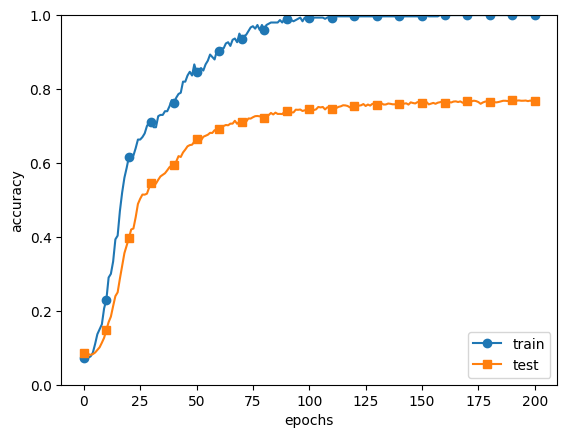

In [16]:
import matplotlib.pyplot as plt

print("With no regulation")

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

With Weight Decay,
epoch:0, train acc:0.17666666666666667, test acc:0.1517
epoch:1, train acc:0.21333333333333335, test acc:0.187
epoch:2, train acc:0.24333333333333335, test acc:0.213
epoch:3, train acc:0.26, test acc:0.2246
epoch:4, train acc:0.27, test acc:0.2241
epoch:5, train acc:0.30666666666666664, test acc:0.2444
epoch:6, train acc:0.32, test acc:0.2689
epoch:7, train acc:0.3466666666666667, test acc:0.2855
epoch:8, train acc:0.35, test acc:0.3025
epoch:9, train acc:0.3466666666666667, test acc:0.3
epoch:10, train acc:0.3566666666666667, test acc:0.3138
epoch:11, train acc:0.38, test acc:0.3279
epoch:12, train acc:0.4033333333333333, test acc:0.3445
epoch:13, train acc:0.41333333333333333, test acc:0.3485
epoch:14, train acc:0.4266666666666667, test acc:0.3643
epoch:15, train acc:0.4533333333333333, test acc:0.3756
epoch:16, train acc:0.47, test acc:0.3838
epoch:17, train acc:0.48333333333333334, test acc:0.3941
epoch:18, train acc:0.49666666666666665, test acc:0.3999
epoch:19,

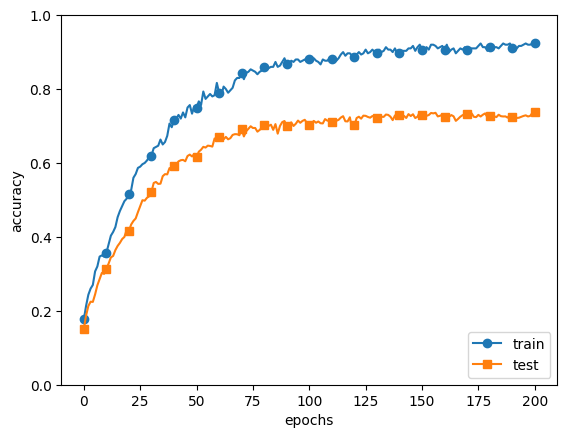

In [17]:
print("With Weight Decay,")

x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

#network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                        weight_decay_lambda=0.001)
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

# 정규화 기법 x 옵티마이저 전체 조합 비교

Weight Decay / Dropout / Batch Normalization의 모든 조합(2^3 = 8가지)에 SGD, Adam을 각각 적용해 총 16가지 학습 곡선을 비교합니다.

In [18]:
import itertools


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

# 조합이 16가지라 평가는 테스트 데이터 일부만 사용 (전체를 쓰면 시간이 오래 걸림)
x_test_sub = x_test[:1000]
t_test_sub = t_test[:1000]

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100
iter_per_epoch = max(train_size / batch_size, 1)

weight_decay_lambda = 0.1
dropout_ration = 0.2


def combo_label(use_weight_decay, use_dropout, use_batchnorm):
    """정규화 조합 이름"""
    names = []
    if use_weight_decay : names.append('WeightDecay')
    if use_dropout : names.append('Dropout')
    if use_batchnorm : names.append('BatchNorm')

    return ' + '.join(names) if names else 'No regularization'


def train_network(use_weight_decay, use_dropout, use_batchnorm, optimizer_name):
    """정규화 조합 하나를 학습하고 epoch별 정확도 리스트를 반환"""
    np.random.seed(0)   # 조합끼리 공정하게 비교하도록 초기 가중치와 배치 순서를 고정

    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                            weight_decay_lambda=weight_decay_lambda if use_weight_decay else 0,
                            use_dropout=use_dropout, dropout_ration=dropout_ration,
                            use_batchnorm=use_batchnorm)

    if optimizer_name == 'SGD':
        optimizer = SGD(lr=0.01)
    else:
        optimizer = Adam(lr=0.001, beta1=0.9, beta2=0.999)

    train_acc_list = []
    test_acc_list = []
    epoch_cnt = 0

    for i in range(1000000000):   # 과적합 유도
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc_list.append(network.accuracy(x_train, t_train))
            test_acc_list.append(network.accuracy(x_test_sub, t_test_sub))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, test_acc_list


# 정규화 3종의 모든 부분집합(8가지) x 옵티마이저 2종 = 16가지
regularization_combos = list(itertools.product([False, True], repeat=3))
optimizer_names = ['SGD', 'Adam']

results = {}
for use_weight_decay, use_dropout, use_batchnorm in regularization_combos:
    for optimizer_name in optimizer_names:
        label = combo_label(use_weight_decay, use_dropout, use_batchnorm)
        print(f'training... {label} / {optimizer_name}')

        train_acc_list, test_acc_list = train_network(use_weight_decay, use_dropout, use_batchnorm, optimizer_name)
        results[(use_weight_decay, use_dropout, use_batchnorm, optimizer_name)] = (train_acc_list, test_acc_list)

        print(f'  train acc: {train_acc_list[-1]:.4f}, test acc: {test_acc_list[-1]:.4f}')

training... No regularization / SGD
  train acc: 1.0000, test acc: 0.7320
training... No regularization / Adam
  train acc: 1.0000, test acc: 0.7620
training... BatchNorm / SGD
  train acc: 1.0000, test acc: 0.5440
training... BatchNorm / Adam
  train acc: 1.0000, test acc: 0.7110
training... Dropout / SGD
  train acc: 0.5367, test acc: 0.4050
training... Dropout / Adam
  train acc: 1.0000, test acc: 0.7710
training... Dropout + BatchNorm / SGD
  train acc: 0.9167, test acc: 0.6140
training... Dropout + BatchNorm / Adam
  train acc: 1.0000, test acc: 0.7660
training... WeightDecay / SGD
  train acc: 0.9200, test acc: 0.7000
training... WeightDecay / Adam
  train acc: 0.9100, test acc: 0.6580
training... WeightDecay + BatchNorm / SGD
  train acc: 1.0000, test acc: 0.6030
training... WeightDecay + BatchNorm / Adam
  train acc: 0.9733, test acc: 0.7370
training... WeightDecay + Dropout / SGD
  train acc: 0.1300, test acc: 0.1260
training... WeightDecay + Dropout / Adam
  train acc: 0.1300

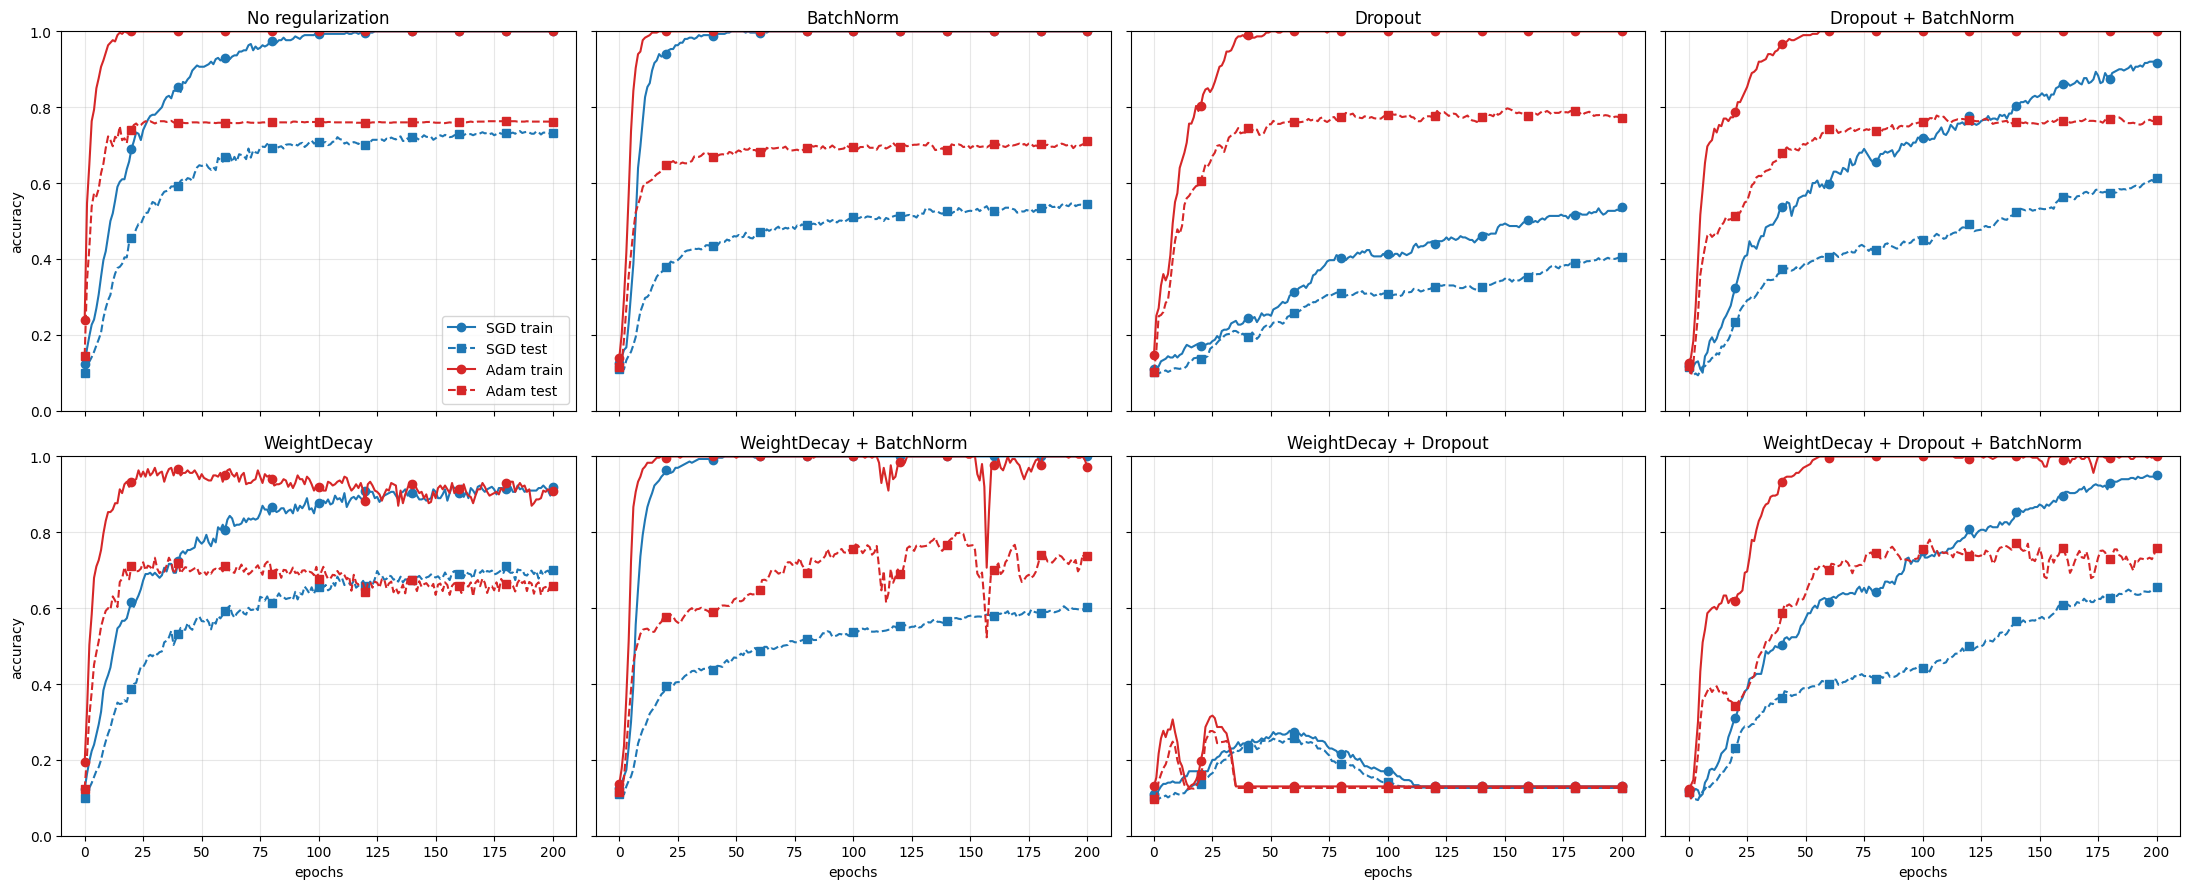

regularization                    optimizer    train acc  test acc       gap
No regularization                 SGD             1.0000    0.7320    0.2680
No regularization                 Adam            1.0000    0.7620    0.2380
BatchNorm                         SGD             1.0000    0.5440    0.4560
BatchNorm                         Adam            1.0000    0.7110    0.2890
Dropout                           SGD             0.5367    0.4050    0.1317
Dropout                           Adam            1.0000    0.7710    0.2290
Dropout + BatchNorm               SGD             0.9167    0.6140    0.3027
Dropout + BatchNorm               Adam            1.0000    0.7660    0.2340
WeightDecay                       SGD             0.9200    0.7000    0.2200
WeightDecay                       Adam            0.9100    0.6580    0.2520
WeightDecay + BatchNorm           SGD             1.0000    0.6030    0.3970
WeightDecay + BatchNorm           Adam            0.9733    0.7370    0.2363

In [19]:
x = np.arange(max_epochs)
optimizer_colors = {'SGD': 'C0', 'Adam': 'C3'}

# 정규화 조합별로 하나의 subplot, 그 안에서 SGD와 Adam을 비교
fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharex=True, sharey=True)

for ax, combo in zip(axes.flatten(), regularization_combos):
    for optimizer_name in optimizer_names:
        train_acc_list, test_acc_list = results[combo + (optimizer_name,)]
        color = optimizer_colors[optimizer_name]
        ax.plot(x, train_acc_list, color=color, marker='o', markevery=20, label=optimizer_name + ' train')
        ax.plot(x, test_acc_list, color=color, marker='s', markevery=20, linestyle='--', label=optimizer_name + ' test')

    ax.set_title(combo_label(*combo))
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("epochs")
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy")

axes[0][0].legend(loc='lower right')
plt.tight_layout()
plt.show()


# 마지막 epoch 기준 요약 (gap이 작을수록 과적합이 덜 일어난 것)
print(f'{"regularization":<34}{"optimizer":<12}{"train acc":>10}{"test acc":>10}{"gap":>10}')
for combo in regularization_combos:
    for optimizer_name in optimizer_names:
        train_acc_list, test_acc_list = results[combo + (optimizer_name,)]
        train_acc, test_acc = train_acc_list[-1], test_acc_list[-1]
        print(f'{combo_label(*combo):<34}{optimizer_name:<12}{train_acc:>10.4f}{test_acc:>10.4f}{train_acc - test_acc:>10.4f}')

# 학습량을 늘렸을 때의 전체 조합 비교

앞의 비교는 300개 데이터 / 201 epoch 기준이라 과적합이 심한 상황입니다.

데이터를 2000개, epoch을 300으로 늘려 충분히 학습시킨 경우를 같은 16가지 조합으로 다시 비교합니다. (나머지 조건은 앞 셀과 동일)

In [20]:
from torchvision import datasets

# 앞 셀에서 x_train이 300개로 잘렸으므로 원본 데이터를 다시 불러옴
mnist_train = datasets.MNIST(root='./data', train=True, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, download=True)

x_train_big = mnist_train.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_train_big = np.eye(10)[mnist_train.targets]
x_test_big = mnist_test.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_test_big = np.eye(10)[mnist_test.targets]

x_train_big = x_train_big[:2000]   # 300개 -> 2000개
t_train_big = t_train_big[:2000]

x_test_sub_big = x_test_big[:1000]   # 조합이 16가지라 평가는 테스트 데이터 일부만 사용
t_test_sub_big = t_test_big[:1000]

max_epochs_big = 300   # 201 epoch -> 300 epoch
train_size_big = x_train_big.shape[0]
batch_size = 100
iter_per_epoch_big = max(train_size_big / batch_size, 1)

# weight_decay_lambda, dropout_ration, 옵티마이저 설정, 조합 목록은 앞 셀과 동일한 값을 그대로 사용


def train_network_big(use_weight_decay, use_dropout, use_batchnorm, optimizer_name):
    """학습량을 늘린 조건으로 정규화 조합 하나를 학습하고 epoch별 정확도 리스트를 반환"""
    np.random.seed(0)   # 조합끼리 공정하게 비교하도록 초기 가중치와 배치 순서를 고정

    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                            weight_decay_lambda=weight_decay_lambda if use_weight_decay else 0,
                            use_dropout=use_dropout, dropout_ration=dropout_ration,
                            use_batchnorm=use_batchnorm)

    if optimizer_name == 'SGD':
        optimizer = SGD(lr=0.01)
    else:
        optimizer = Adam(lr=0.001, beta1=0.9, beta2=0.999)

    train_acc_list = []
    test_acc_list = []
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size_big, batch_size)
        x_batch = x_train_big[batch_mask]
        t_batch = t_train_big[batch_mask]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        if i % iter_per_epoch_big == 0:
            train_acc_list.append(network.accuracy(x_train_big, t_train_big))
            test_acc_list.append(network.accuracy(x_test_sub_big, t_test_sub_big))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs_big:
                break

    return train_acc_list, test_acc_list


results_big = {}
for use_weight_decay, use_dropout, use_batchnorm in regularization_combos:
    for optimizer_name in optimizer_names:
        label = combo_label(use_weight_decay, use_dropout, use_batchnorm)
        print(f'training... {label} / {optimizer_name}')

        train_acc_list, test_acc_list = train_network_big(use_weight_decay, use_dropout, use_batchnorm, optimizer_name)
        results_big[(use_weight_decay, use_dropout, use_batchnorm, optimizer_name)] = (train_acc_list, test_acc_list)

        print(f'  train acc: {train_acc_list[-1]:.4f}, test acc: {test_acc_list[-1]:.4f}')

training... No regularization / SGD
  train acc: 1.0000, test acc: 0.8860
training... No regularization / Adam
  train acc: 1.0000, test acc: 0.9010
training... BatchNorm / SGD
  train acc: 1.0000, test acc: 0.8550
training... BatchNorm / Adam
  train acc: 1.0000, test acc: 0.9020
training... Dropout / SGD
  train acc: 0.9925, test acc: 0.8880
training... Dropout / Adam
  train acc: 1.0000, test acc: 0.9120
training... Dropout + BatchNorm / SGD
  train acc: 0.9975, test acc: 0.8860
training... Dropout + BatchNorm / Adam
  train acc: 1.0000, test acc: 0.8890
training... WeightDecay / SGD
  train acc: 0.7930, test acc: 0.7540
training... WeightDecay / Adam
  train acc: 0.7445, test acc: 0.6970
training... WeightDecay + BatchNorm / SGD
  train acc: 0.9920, test acc: 0.8450
training... WeightDecay + BatchNorm / Adam
  train acc: 0.9735, test acc: 0.8600
training... WeightDecay + Dropout / SGD
  train acc: 0.1120, test acc: 0.0990
training... WeightDecay + Dropout / Adam
  train acc: 0.1120

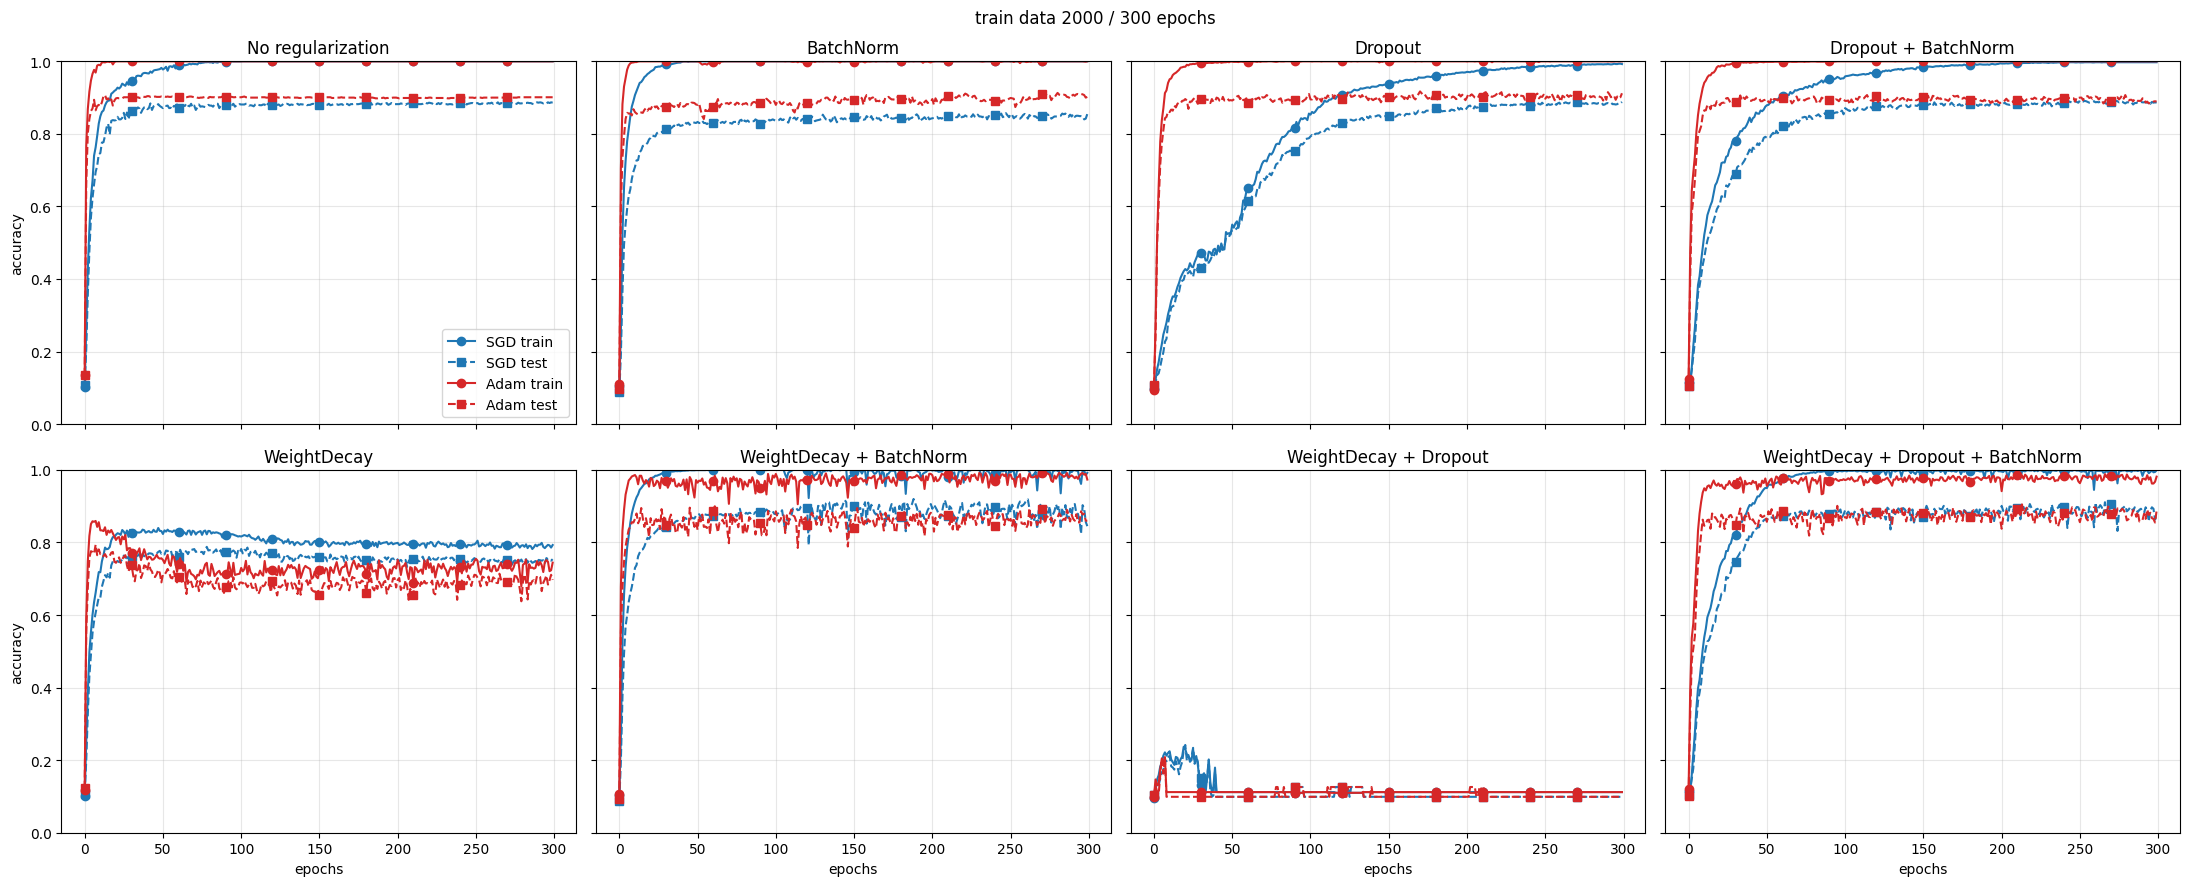

regularization                    optimizer    train acc  test acc       gap
No regularization                 SGD             1.0000    0.8860    0.1140
No regularization                 Adam            1.0000    0.9010    0.0990
BatchNorm                         SGD             1.0000    0.8550    0.1450
BatchNorm                         Adam            1.0000    0.9020    0.0980
Dropout                           SGD             0.9925    0.8880    0.1045
Dropout                           Adam            1.0000    0.9120    0.0880
Dropout + BatchNorm               SGD             0.9975    0.8860    0.1115
Dropout + BatchNorm               Adam            1.0000    0.8890    0.1110
WeightDecay                       SGD             0.7930    0.7540    0.0390
WeightDecay                       Adam            0.7445    0.6970    0.0475
WeightDecay + BatchNorm           SGD             0.9920    0.8450    0.1470
WeightDecay + BatchNorm           Adam            0.9735    0.8600    0.1135

In [21]:
x = np.arange(max_epochs_big)
optimizer_colors = {'SGD': 'C0', 'Adam': 'C3'}

# 정규화 조합별로 하나의 subplot, 그 안에서 SGD와 Adam을 비교
fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharex=True, sharey=True)

for ax, combo in zip(axes.flatten(), regularization_combos):
    for optimizer_name in optimizer_names:
        train_acc_list, test_acc_list = results_big[combo + (optimizer_name,)]
        color = optimizer_colors[optimizer_name]
        ax.plot(x, train_acc_list, color=color, marker='o', markevery=30, label=optimizer_name + ' train')
        ax.plot(x, test_acc_list, color=color, marker='s', markevery=30, linestyle='--', label=optimizer_name + ' test')

    ax.set_title(combo_label(*combo))
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("epochs")
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy")

axes[0][0].legend(loc='lower right')
fig.suptitle(f'train data {train_size_big} / {max_epochs_big} epochs')
plt.tight_layout()
plt.show()


# 마지막 epoch 기준 요약 (gap이 작을수록 과적합이 덜 일어난 것)
print(f'{"regularization":<34}{"optimizer":<12}{"train acc":>10}{"test acc":>10}{"gap":>10}')
for combo in regularization_combos:
    for optimizer_name in optimizer_names:
        train_acc_list, test_acc_list = results_big[combo + (optimizer_name,)]
        train_acc, test_acc = train_acc_list[-1], test_acc_list[-1]
        print(f'{combo_label(*combo):<34}{optimizer_name:<12}{train_acc:>10.4f}{test_acc:>10.4f}{train_acc - test_acc:>10.4f}')